In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("data/processed/train.csv")
test = pd.read_csv("data/processed/test.csv")

In [3]:
X_train = train.drop("Converted", axis=1)
y_train = train["Converted"]

X_test = test.drop("Converted", axis=1)
y_test = test["Converted"]

In [4]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

C:\Ecommerce Purchase Intent Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [8]:
def evaluate_model(name, y_true, y_pred):

    print("=" * 40)
    print(name)
    print("=" * 40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

In [9]:
evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Random Forest", y_test, rf_pred)

Logistic Regression
Accuracy : 0.9295833333333333
Precision: 0.8398692810457516
Recall   : 0.6816976127320955
F1 Score : 0.7525622254758418

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2023
           1       0.84      0.68      0.75       377

    accuracy                           0.93      2400
   macro avg       0.89      0.83      0.86      2400
weighted avg       0.93      0.93      0.93      2400

Decision Tree
Accuracy : 0.8925
Precision: 0.6561679790026247
Recall   : 0.6631299734748011
F1 Score : 0.6596306068601583

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2023
           1       0.66      0.66      0.66       377

    accuracy                           0.89      2400
   macro avg       0.80      0.80      0.80      2400
weighted avg       0.89      0.89      0.89      2400

Random Forest
Accuracy : 0.930416666

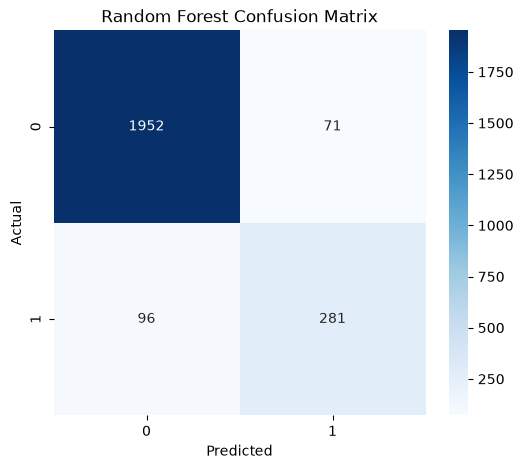

In [10]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [11]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

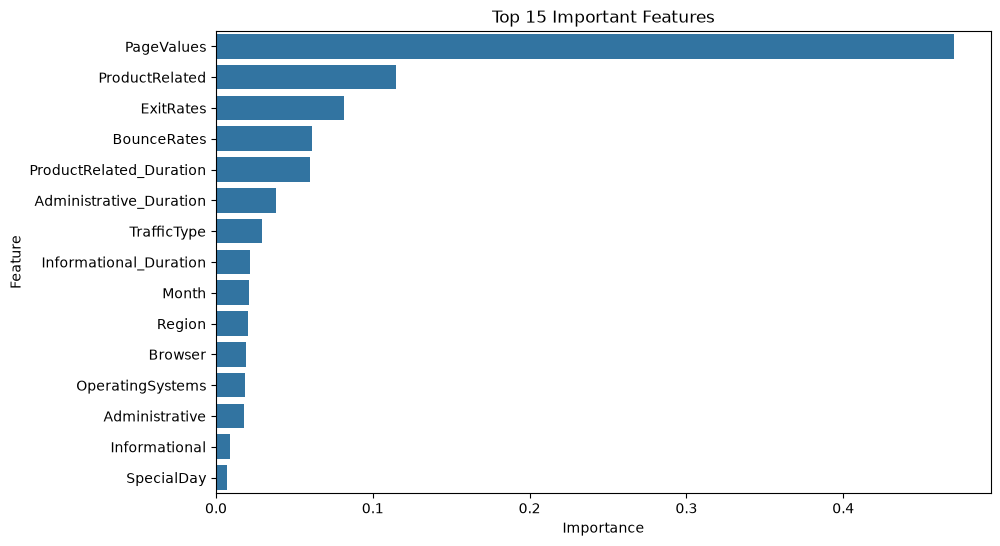

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [14]:
import joblib

joblib.dump(rf, "models/random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!
